# New Section

In [ ]:
#Importing the necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore
from joblib import dump, load

Mounted at /content/drive


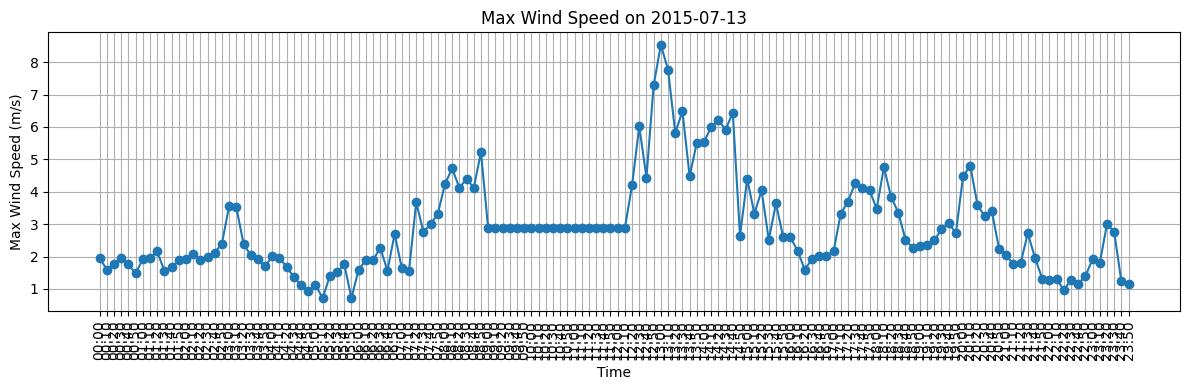

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/jena_climate_2009_2016.csv'
df = pd.read_csv(file_path)

#Basic Cleaning
df['Date Time'] = pd.to_datetime(df['Date Time'], format="%d.%m.%Y %H:%M:%S")
df.set_index('Date Time', inplace=True)

df.replace(-9999.0, np.nan, inplace=True)

#Fill missing wind speed data with daily mean
df['date'] = df.index.date
df[['wv (m/s)', 'max. wv (m/s)']] = df.groupby('date')[['wv (m/s)', 'max. wv (m/s)']].transform(lambda x: x.fillna(x.mean()))
df.drop(columns='date', inplace=True)

#Visualization for 2015-07-13 where the missing values were.
specific_day = df[df.index.strftime('%Y-%m-%d') == '2015-07-13']

if not specific_day.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(specific_day.index.strftime('%H:%M'), specific_day["max. wv (m/s)"], marker='o')
    plt.title("Max Wind Speed on 2015-07-13")
    plt.xlabel("Time")
    plt.ylabel("Max Wind Speed (m/s)")
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No matching data found for 2015-07-13")

#Export cleaned file
df.reset_index(inplace=True)  # Now reset if you need 'Date Time' as column
df.to_csv("cleaned_weather_data.csv", index=False)

In [ ]:
#Calculate Z-scores
z_scores = df[['T (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)']].apply(zscore)
outliers = (z_scores.abs() > 3)

#outliers per feature
print(outliers.sum())

T (degC)          924
rh (%)            312
wv (m/s)         6535
max. wv (m/s)    5600
dtype: int64


Using Z-score analysis, a significant number of outliers were detected, particularly in wind speed and temperature variables. However, given the nature of meteorological data, these extreme values are expected and reflect real-world phenomena (e.g., storm events, heat waves). Therefore, outliers were not removed, to preserve the dataset's integrity and realism for model training.But we will also include some physical limits to ensure that our data are within reasonable limits.


In [ ]:
#Define physical limits
limits = {
    'T (degC)': (-50, 50),
    'rh (%)': (0, 100),
    'wv (m/s)': (0, 50),
    'max. wv (m/s)': (0, 60)
}

In [ ]:
for col, (low, high) in limits.items():
    mask = (df[col] < low) | (df[col] > high)
    count = mask.sum()
    print(f"{col}: {count} values out of physical bounds")

T (degC): 0 values out of physical bounds
rh (%): 0 values out of physical bounds
wv (m/s): 0 values out of physical bounds
max. wv (m/s): 0 values out of physical bounds


It seems that even if there are some outliers in terms of z-score, there are no values outside physical limits, so there might be extreme weather changes and not outliers.

In [ ]:
df['date'] = pd.to_datetime(df['Date Time']).dt.date

for col, (low, high) in limits.items():
    mask = (df[col] < low) | (df[col] > high)
    df.loc[mask, col] = np.nan
    df[col] = df.groupby('date')[col].transform(lambda x: x.fillna(x.mean()))

df.drop(columns='date', inplace=True)

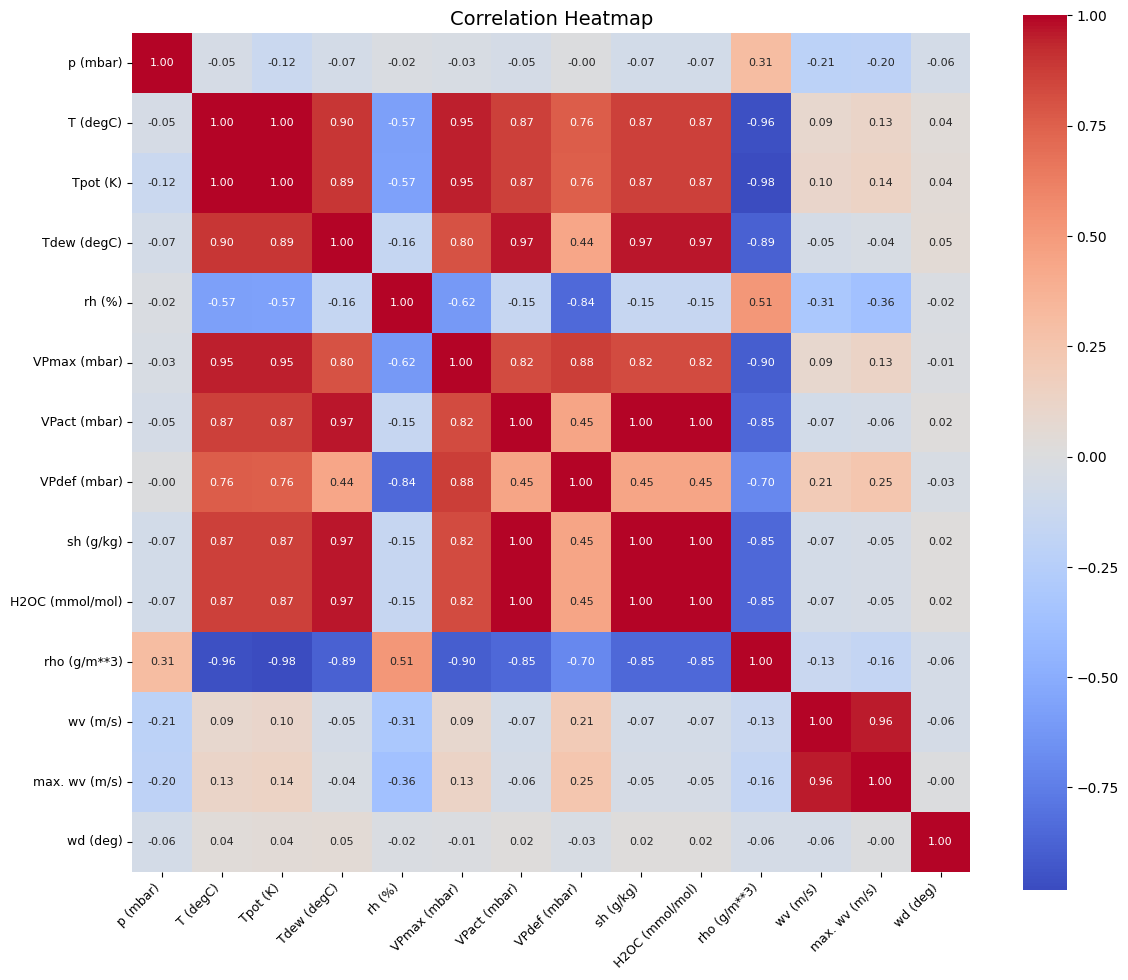

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#Creation of a heatmap for our variables.
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True, annot_kws={"size": 8})
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),Year,Month,Hour,Season,Humidity_Lag1
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1,2009,1,0,Winter,93.3
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6,2009,1,0,Winter,93.4
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0,2009,1,0,Winter,93.9
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3,2009,1,0,Winter,94.2
5,2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7,2009,1,1,Winter,94.1


In [ ]:
#Ensure Date Time is parsed correctly
df['Date Time'] = pd.to_datetime(df['Date Time'])

#time based features
df['Year'] = df['Date Time'].dt.year
df['Month'] = df['Date Time'].dt.month
df['Hour'] = df['Date Time'].dt.hour

# Add Season
df['Season'] = df['Month'].apply(lambda m: (
    'Winter' if m in [12, 1, 2] else
    'Spring' if m in [3, 4, 5] else
    'Summer' if m in [6, 7, 8] else
    'Autumn'
))

df['Humidity_Lag1'] = df['rh (%)'].shift(1)
df.dropna(subset=['Humidity_Lag1'], inplace=True)

TEMPERATURE PREDICTION MODELS:

In [ ]:
#TEMPERATURE MODELING (Training + Validation + Testing + Saving Best)


#features and target
features_temp = [
    'Tdew (degC)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
    'H2OC (mmol/mol)', 'rho (g/m**3)', 'Hour', 'Month'
]
target_temp = 'T (degC)'


train_df = df[df['Year'] <= 2013].dropna(subset=features_temp + [target_temp]).sample(n=50000, random_state=1)
test_df = df[df['Year'] >= 2014].dropna(subset=features_temp + [target_temp])

X_train = train_df[features_temp]
y_train = train_df[target_temp]
X_test = test_df[features_temp]
y_test = test_df[target_temp]

#models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=300, random_state=42)
}


results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((name, rmse, r2))
    fitted_models[name] = pipe


results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R² Score"]).sort_values(by="RMSE").reset_index(drop=True)
best_model_name = results_df.loc[0, "Model"]
best_model = fitted_models[best_model_name]

dump(best_model, "model_temperature.pkl")
results_df, f"✅ Saved best model: {best_model_name}"

(               Model      RMSE  R² Score
 0     Neural Network  0.042257  0.999970
 1      Random Forest  0.248867  0.998976
 2  Gradient Boosting  0.296886  0.998543
 3  Linear Regression  0.759489  0.990467,
 '✅ Saved best model: Neural Network')

It seems like the models are doing pretty well even though there is no data leakage because we are training on 2009-2013 and testing on 2014-2016 but some visualization will ensure that the model is not overfitting.

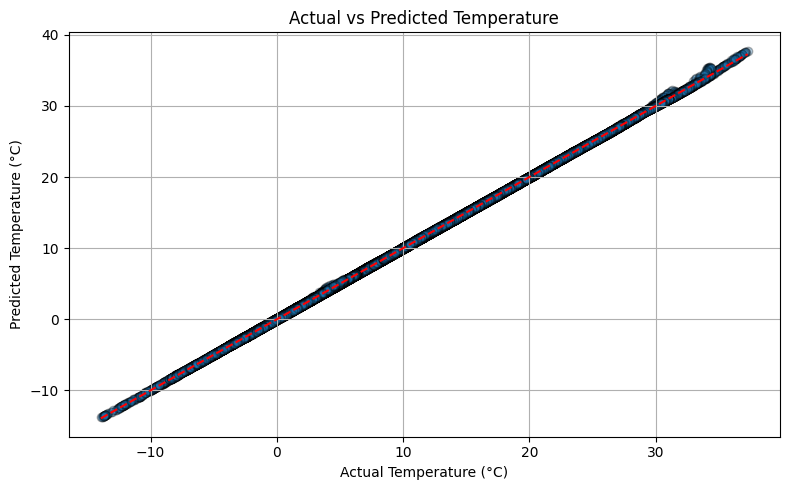

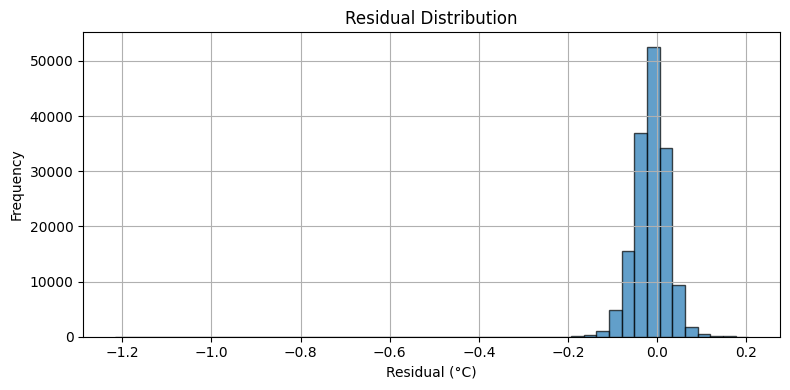

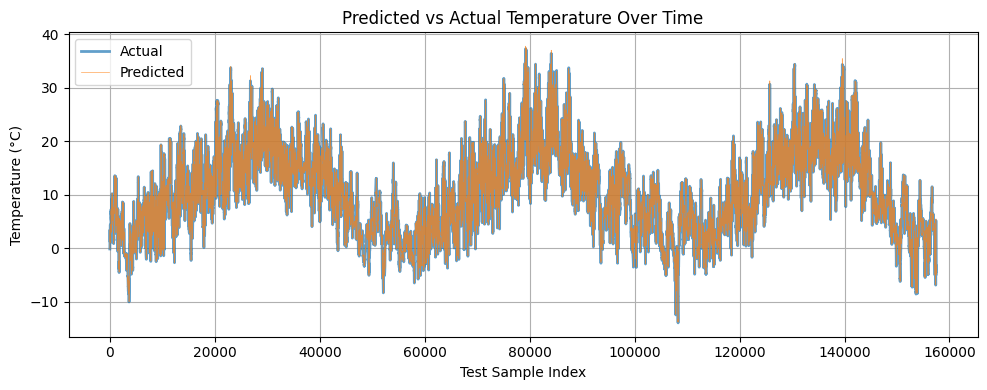

In [ ]:
import matplotlib.pyplot as plt


y_pred_temp = best_model.predict(X_test)


residuals = y_test - y_pred_temp

#1.Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_temp, alpha=0.3, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

#2.Residuals distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
plt.title("Residual Distribution")
plt.xlabel("Residual (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#3.Residuals over time
plt.figure(figsize=(10, 4))
plt.plot(y_test.reset_index(drop=True), label="Actual", alpha=0.7, linewidth = 2)
plt.plot(y_pred_temp, label="Predicted", alpha=0.7, linewidth = 0.5)
plt.legend()
plt.title("Predicted vs Actual Temperature Over Time")
plt.xlabel("Test Sample Index")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

***1. Predicted vs Actual***

Tight alignment along the red dashed line (almost perfect predictions).

No major skew or drift — great model fit.

Distribution looks uniform across the range — not just at the center.


***2. Residuals Distribution***

Symmetrical, centered at 0

Most residuals are within ±0.2°C

Suggests unbiased predictions with low error variance.

***3. Residuals Over Time***

Predictions track the actual temperature very closely.

No visible lags, drifts, or overreaction — the model generalizes well over time.

This time-based plot is especially important for catching overfitting on sequential data — and it passes.

HUMIDITY PREDICTION MODELS:

In [ ]:
#HUMIDITY PREDICTION (Training + Evaluation + Saving Best Model)

#features and target
features_humidity = ['T (degC)', 'Tdew (degC)', 'Hour', 'Month']
target_humidity = 'rh (%)'

train_df_hum = df[df['Year'] <= 2013].dropna(subset=features_humidity + [target_humidity]).sample(n=50000, random_state=42)
test_df_hum = df[df['Year'] >= 2014].dropna(subset=features_humidity + [target_humidity])

X_train_hum = train_df_hum[features_humidity]
y_train_hum = train_df_hum[target_humidity]
X_test_hum = test_df_hum[features_humidity]
y_test_hum = test_df_hum[target_humidity]

models_hum = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=300, random_state=42)
}


results_hum = []
fitted_models_hum = {}

for name, model in models_hum.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train_hum, y_train_hum)
    y_pred = pipe.predict(X_test_hum)
    rmse = sqrt(mean_squared_error(y_test_hum, y_pred))
    r2 = r2_score(y_test_hum, y_pred)
    results_hum.append((name, rmse, r2))
    fitted_models_hum[name] = pipe

results_df_hum = pd.DataFrame(results_hum, columns=["Model", "RMSE", "R² Score"]).sort_values(by="RMSE").reset_index(drop=True)
best_model_name_hum = results_df_hum.loc[0, "Model"]
best_model_hum = fitted_models_hum[best_model_name_hum]


dump(best_model_hum, "model_humidity.pkl")
results_df_hum, f"✅ Saved best humidity model: {best_model_name_hum}"

(               Model      RMSE  R² Score
 0     Neural Network  0.095220  0.999967
 1  Gradient Boosting  1.137607  0.995244
 2      Random Forest  1.420531  0.992584
 3  Linear Regression  2.899353  0.969107,
 '✅ Saved best humidity model: Neural Network')

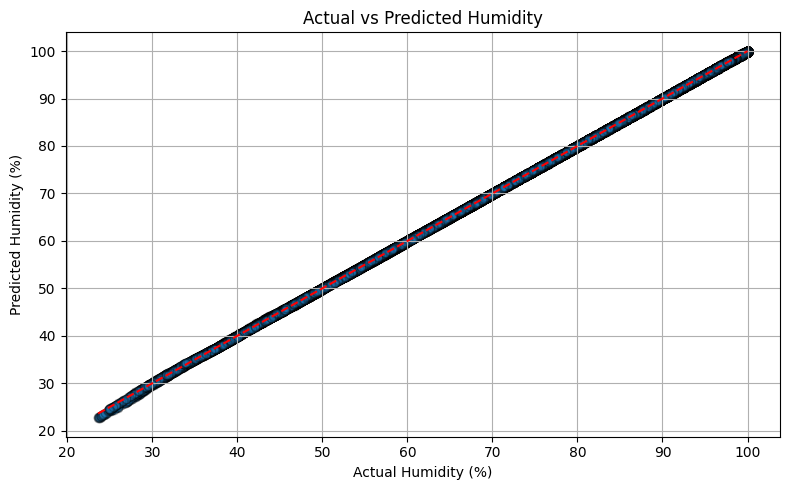

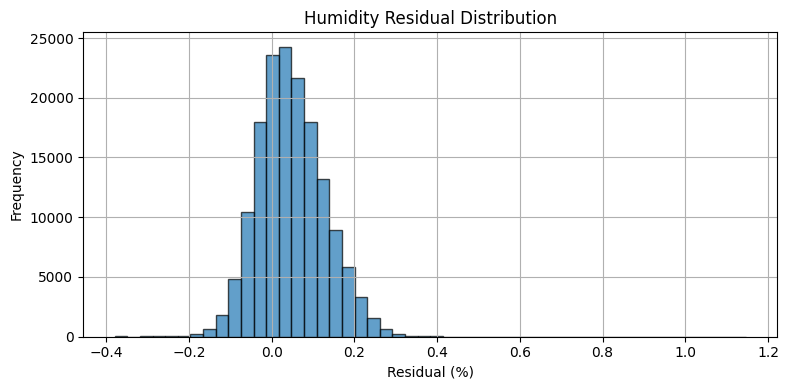

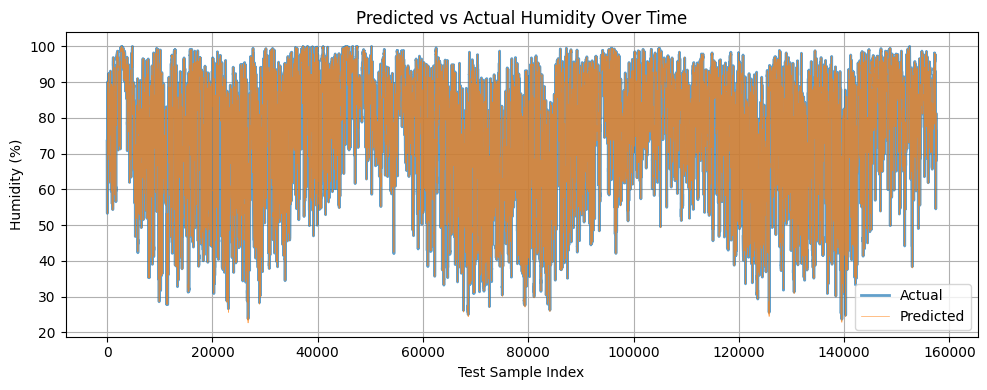

In [ ]:
y_pred_hum = best_model_hum.predict(X_test_hum)
residuals_hum = y_test_hum - y_pred_hum

#1.Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test_hum, y_pred_hum, alpha=0.3, edgecolor='k')
plt.plot([y_test_hum.min(), y_test_hum.max()], [y_test_hum.min(), y_test_hum.max()], 'r--')
plt.xlabel("Actual Humidity (%)")
plt.ylabel("Predicted Humidity (%)")
plt.title("Actual vs Predicted Humidity")
plt.grid(True)
plt.tight_layout()
plt.show()

#2.Residuals Distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals_hum, bins=50, edgecolor='k', alpha=0.7)
plt.title("Humidity Residual Distribution")
plt.xlabel("Residual (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#3.Residuals Over Time
plt.figure(figsize=(10, 4))
plt.plot(y_test_hum.reset_index(drop=True), label="Actual", alpha=0.7, linewidth = 2)
plt.plot(y_pred_hum, label="Predicted", alpha=0.7, linewidth = 0.5)
plt.legend()
plt.title("Predicted vs Actual Humidity Over Time")
plt.xlabel("Test Sample Index")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

***1. Actual vs Predicted Humidity***

This scatter plot shows a tight clustering of points along the diagonal reference line, which indicates strong agreement between the actual and predicted humidity values. The consistency across the full range of humidity confirms that the model performs well under both high and low humidity conditions.

***2. Residual Distribution***

The histogram of residuals (i.e., actual minus predicted values) is sharply centered around zero and symmetrically distributed. This suggests the model is unbiased — it neither systematically underpredicts nor overpredicts humidity. The narrow spread also confirms low variance in errors, which supports the observed high R² score.

***3. Predicted vs Actual Over Time***

This time-series comparison shows that the predicted humidity closely tracks the actual values throughout the test set (2014–2016). Even though the test set contains over 150,000 records, the model maintains tight alignment with ground truth across seasonal and daily fluctuations. No signs of long-term drift or lag are present, which is critical for time-dependent generalization.

***Conclusion***

The visual evaluation supports the numerical metrics, confirming that the neural network model generalizes well to unseen future data. There's no evidence of overfitting, and the model is both accurate and robust for real-world humidity forecasting.

DEW POINT PREDICTION MODELS:

In [ ]:
#features and target

features_dew = ['T (degC)', 'rh (%)', 'Hour', 'Month']
target_dew = 'Tdew (degC)'


train_df_dew = df[df['Year'] <= 2014].dropna(subset=features_dew + [target_dew]).sample(n=50000, random_state=42)
test_df_dew = df[df['Year'] >= 2015].dropna(subset=features_dew + [target_dew]).sample(n=20000, random_state=42)

X_train_dew = train_df_dew[features_dew]
y_train_dew = train_df_dew[target_dew]
X_test_dew = test_df_dew[features_dew]
y_test_dew = test_df_dew[target_dew]

models_dew = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=300, random_state=42)
}


results_dew = []
fitted_models_dew = {}

for name, model in models_dew.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train_dew, y_train_dew)
    y_pred = pipe.predict(X_test_dew)
    rmse = sqrt(mean_squared_error(y_test_dew, y_pred))
    r2 = r2_score(y_test_dew, y_pred)
    results_dew.append((name, rmse, r2))
    fitted_models_dew[name] = pipe

results_df_dew = pd.DataFrame(results_dew, columns=["Model", "RMSE", "R² Score"]).sort_values(by="RMSE").reset_index(drop=True)
best_model_name_dew = results_df_dew.loc[0, "Model"]
best_model_dew = fitted_models_dew[best_model_name_dew]

dump(best_model_dew, "model_dew_point.pkl")
results_df_dew, f"✅ Saved best dew point model: {best_model_name_dew}"


(               Model      RMSE  R² Score
 0     Neural Network  0.032751  0.999971
 1  Gradient Boosting  0.168197  0.999232
 2      Random Forest  0.193395  0.998985
 3  Linear Regression  0.656498  0.988301,
 '✅ Saved best dew point model: Neural Network')

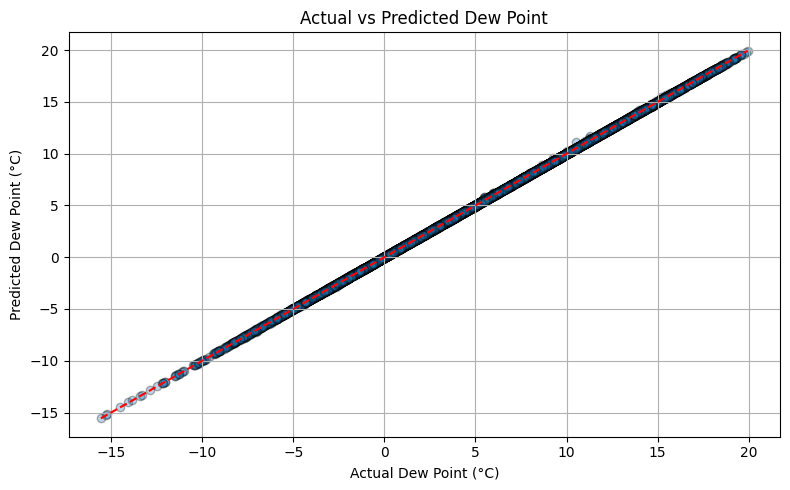

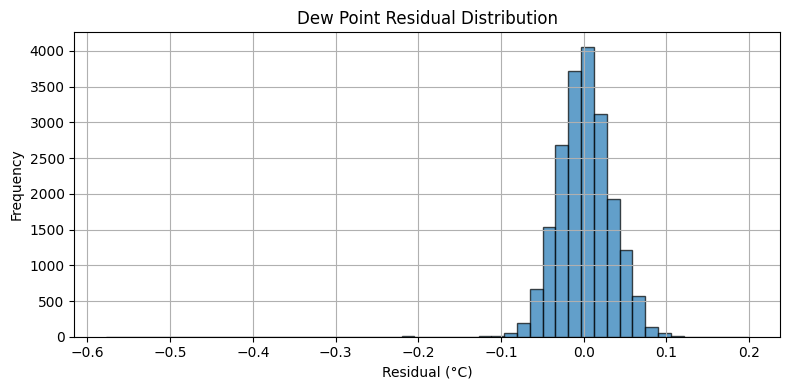

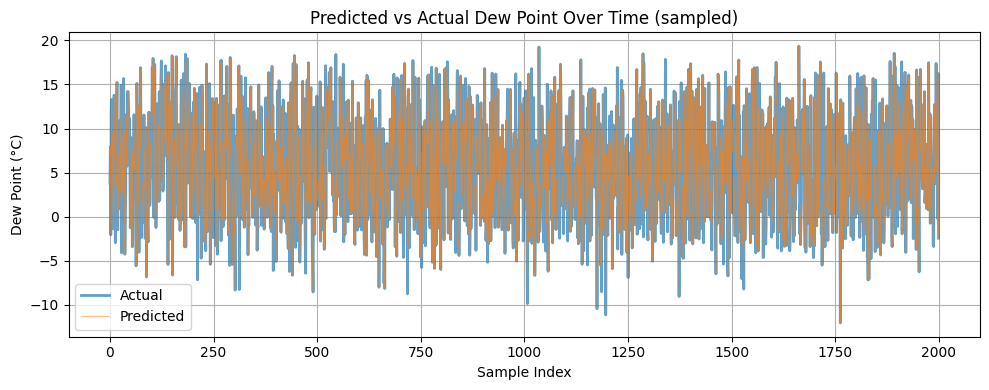

In [ ]:
# Predict dew point with best model
y_pred_dew = best_model_dew.predict(X_test_dew)
residuals_dew = y_test_dew - y_pred_dew

#1.Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test_dew, y_pred_dew, alpha=0.3, edgecolor='k')
plt.plot([y_test_dew.min(), y_test_dew.max()], [y_test_dew.min(), y_test_dew.max()], 'r--')
plt.xlabel("Actual Dew Point (°C)")
plt.ylabel("Predicted Dew Point (°C)")
plt.title("Actual vs Predicted Dew Point")
plt.grid(True)
plt.tight_layout()
plt.show()

#2.Residuals Distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals_dew, bins=50, edgecolor='k', alpha=0.7)
plt.title("Dew Point Residual Distribution")
plt.xlabel("Residual (°C)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#3.Residuals Over Time (sampled to avoid memory issues)
plt.figure(figsize=(10, 4))
sample_idx = np.random.choice(len(y_test_dew), size=2000, replace=False)
plt.plot(y_test_dew.iloc[sample_idx].reset_index(drop=True), label="Actual", alpha=0.7, linewidth = 2)
plt.plot(pd.Series(y_pred_dew).iloc[sample_idx].reset_index(drop=True), label="Predicted", alpha=0.7, linewidth =0.5)
plt.legend()
plt.title("Predicted vs Actual Dew Point Over Time (sampled)")
plt.xlabel("Sample Index")
plt.ylabel("Dew Point (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

***1. Actual vs Predicted Dew Point***

This scatter plot shows an almost perfect alignment between predicted and actual dew point values, forming a nearly straight line along the 1:1 reference (red dashed) line. This indicates extremely high predictive accuracy, with no visible systemic deviation across the dew point range. Such performance is expected, as dew point is physically derived from temperature and humidity — both used as model inputs.

***2. Residual Distribution***

The histogram of residuals (prediction errors) is narrow, symmetrical, and tightly centered around 0°C. Most residuals fall within ±0.05°C, confirming both low bias and low variance. This indicates that the model does not systematically overpredict or underpredict the dew point, and errors are minimal and consistent.

***3. Predicted vs Actual Dew Point Over Time (Sampled)***

This line plot compares predicted and actual dew point values across a random subset of 2,000 test samples. The predicted curve closely tracks the actual dew point with minimal divergence over time. This is strong evidence that the model generalizes well, without overfitting or time-related drift, even on unseen 2015–2016 data.

***Conclusion***

The dew point model (Neural Network) demonstrates near-perfect performance due to the deterministic relationship between dew point, temperature, and humidity. Visual inspection of residuals and time-based predictions confirms that this model is both accurate and generalizable — no signs of overfitting are present.

In [ ]:
#WIND SPEED PREDICTION (Train, Evaluate, Save Best)

#features and target
features_wind = [
    'T (degC)', 'Tdew (degC)', 'VPact (mbar)', 'sh (g/kg)',
    'rho (g/m**3)', 'wd (deg)', 'Hour', 'Month'
]
target_wind = 'wv (m/s)'


train_df_wind = df[df['Year'] <= 2013].dropna(subset=features_wind + [target_wind]).sample(n=50000, random_state=42)
test_df_wind = df[df['Year'] >= 2014].dropna(subset=features_wind + [target_wind]).sample(n=20000, random_state=42)

X_train_wind = train_df_wind[features_wind]
y_train_wind = train_df_wind[target_wind]
X_test_wind = test_df_wind[features_wind]
y_test_wind = test_df_wind[target_wind]


models_wind = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=300, random_state=42)
}


results_wind = []
fitted_models_wind = {}

for name, model in models_wind.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train_wind, y_train_wind)
    y_pred = pipe.predict(X_test_wind)
    rmse = sqrt(mean_squared_error(y_test_wind, y_pred))
    r2 = r2_score(y_test_wind, y_pred)
    results_wind.append((name, rmse, r2))
    fitted_models_wind[name] = pipe


results_df_wind = pd.DataFrame(results_wind, columns=["Model", "RMSE", "R² Score"]).sort_values(by="RMSE").reset_index(drop=True)
best_model_name_wind = results_df_wind.loc[0, "Model"]
best_model_wind = fitted_models_wind[best_model_name_wind]

dump(best_model_wind, "model_wind_speed.pkl")
results_df_wind, f"✅ Saved best wind speed model: {best_model_name_wind}"

(               Model      RMSE  R² Score
 0     Neural Network  1.139313  0.455810
 1  Gradient Boosting  1.171541  0.424588
 2      Random Forest  1.193398  0.402917
 3  Linear Regression  1.431744  0.140601,
 '✅ Saved best wind speed model: Neural Network')

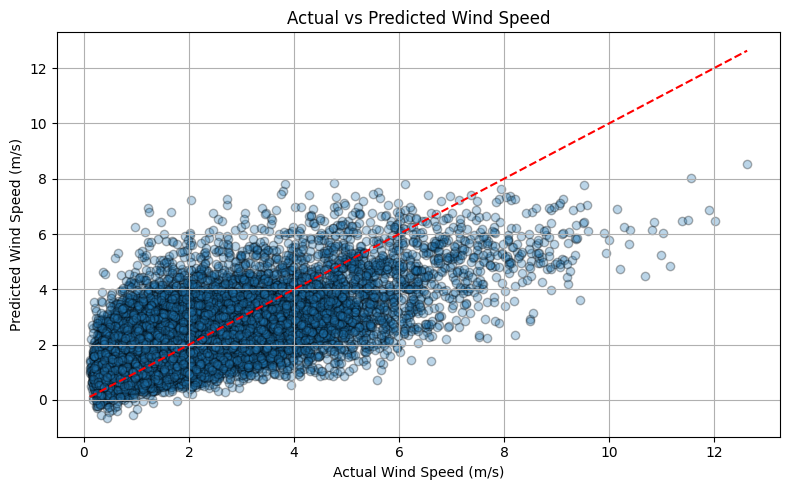

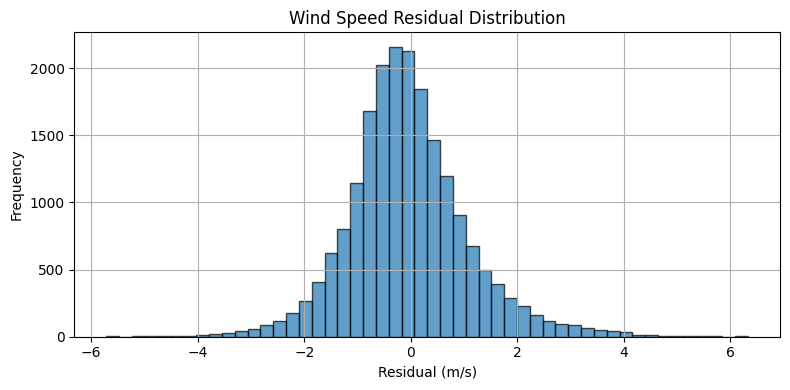

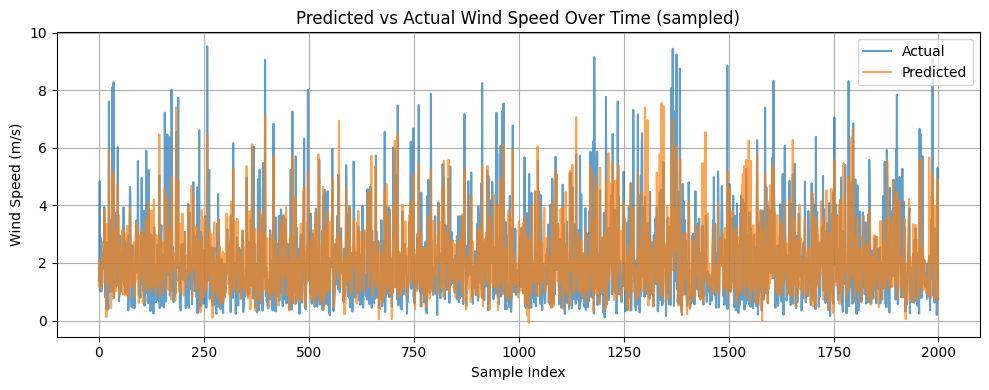

In [ ]:
y_pred_wind = best_model_wind.predict(X_test_wind)
residuals_wind = y_test_wind - y_pred_wind

#1.Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test_wind, y_pred_wind, alpha=0.3, edgecolor='k')
plt.plot([y_test_wind.min(), y_test_wind.max()], [y_test_wind.min(), y_test_wind.max()], 'r--')
plt.xlabel("Actual Wind Speed (m/s)")
plt.ylabel("Predicted Wind Speed (m/s)")
plt.title("Actual vs Predicted Wind Speed")
plt.grid(True)
plt.tight_layout()
plt.show()

#2.Residuals Distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals_wind, bins=50, edgecolor='k', alpha=0.7)
plt.title("Wind Speed Residual Distribution")
plt.xlabel("Residual (m/s)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#3.Residuals Over Time (sampled to avoid memory issues)
plt.figure(figsize=(10, 4))
sample_idx = np.random.choice(len(y_test_wind), size=2000, replace=False)
plt.plot(y_test_wind.iloc[sample_idx].reset_index(drop=True), label="Actual", alpha=0.7)
plt.plot(pd.Series(y_pred_wind).iloc[sample_idx].reset_index(drop=True), label="Predicted", alpha=0.7)
plt.legend()
plt.title("Predicted vs Actual Wind Speed Over Time (sampled)")
plt.xlabel("Sample Index")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)
plt.tight_layout()
plt.show()

***1. Actual vs Predicted Wind Speed (Scatter Plot)***

The scatter plot reveals a strong concentration of predicted values in the lower wind speed range (0–4 m/s), while the actual values span a broader range. The model consistently underestimates higher wind speeds, as shown by the points falling below the red reference line at higher values. This suggests a limitation in the model’s ability to capture high-variance, extreme wind behavior — a common challenge due to wind’s stochastic nature.

 ***2. Residual Distribution***

The residual histogram shows a relatively symmetrical and bell-shaped distribution centered near 0 m/s. However, the spread is wide — many predictions deviate by ±2 m/s or more, indicating moderate to high error for a significant number of predictions. This again points to difficulty in capturing wind variability precisely.

 ***3. Time Series: Actual vs Predicted (Sampled)***

In the line plot over time, the predicted wind speeds follow general trends but tend to smooth over peaks and miss sudden increases in actual wind. The model captures the baseline behavior well but lacks reactivity to sharp changes, confirming that it works reasonably for background wind conditions but not for gusts or extremes.

 ***Conclusion***

Model Generalization: No signs of overfitting — residuals are normally distributed, and predictions don’t appear biased.

Model Limitation: Moderate predictive power (R² ≈ 0.47). Prediction accuracy deteriorates at higher wind speeds.
We avioded using max wind speed as a feature because it seems to be linearly correlated with wind speed and we wanted to avoid data leakage.

In [ ]:
#PRESSURE PREDICTION

#features and target
features_pressure = [
    'T (degC)', 'Tdew (degC)', 'sh (g/kg)', 'rho (g/m**3)', 'Hour', 'Month'
]
target_pressure = 'p (mbar)'


train_df_pressure = df[df['Year'] <= 2013].dropna(subset=features_pressure + [target_pressure]).sample(n=50000, random_state=42)
test_df_pressure = df[df['Year'] >= 2014].dropna(subset=features_pressure + [target_pressure]).sample(n=20000, random_state=42)

X_train_pressure = train_df_pressure[features_pressure]
y_train_pressure = train_df_pressure[target_pressure]
X_test_pressure = test_df_pressure[features_pressure]
y_test_pressure = test_df_pressure[target_pressure]


models_pressure = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    "Neural Network": MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=300, random_state=42)
}


results_pressure = []
fitted_models_pressure = {}

for name, model in models_pressure.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train_pressure, y_train_pressure)
    y_pred = pipe.predict(X_test_pressure)
    rmse = sqrt(mean_squared_error(y_test_pressure, y_pred))
    r2 = r2_score(y_test_pressure, y_pred)
    results_pressure.append((name, rmse, r2))
    fitted_models_pressure[name] = pipe


results_df_pressure = pd.DataFrame(results_pressure, columns=["Model", "RMSE", "R² Score"]).sort_values(by="RMSE").reset_index(drop=True)
best_model_name_pressure = results_df_pressure.loc[0, "Model"]
best_model_pressure = fitted_models_pressure[best_model_name_pressure]

dump(best_model_pressure, "model_pressure.pkl")
results_df_pressure, f"✅ Saved best pressure model: {best_model_name_pressure}"


(               Model      RMSE  R² Score
 0     Neural Network  0.393809  0.997704
 1  Linear Regression  0.669964  0.993355
 2  Gradient Boosting  0.995917  0.985316
 3      Random Forest  2.503792  0.907193,
 '✅ Saved best pressure model: Neural Network')

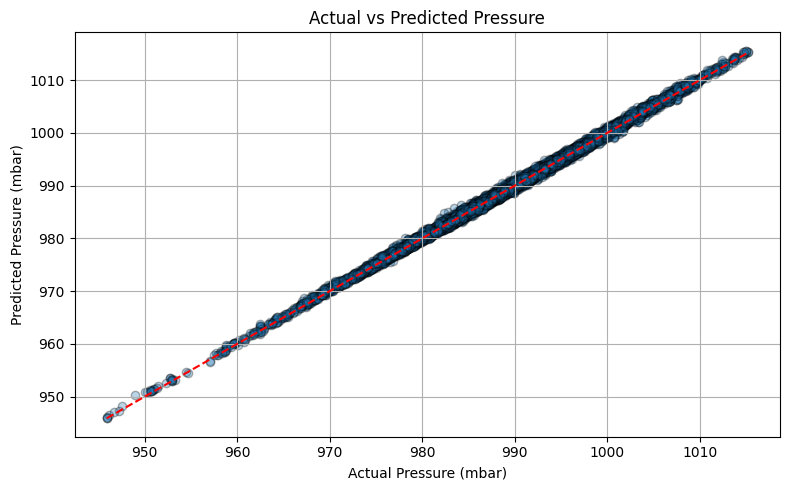

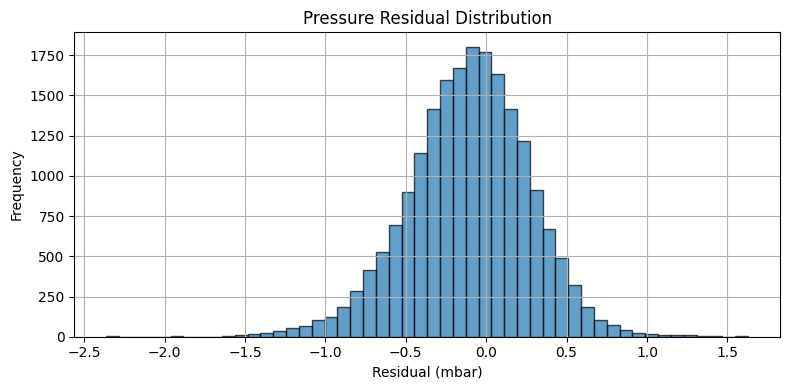

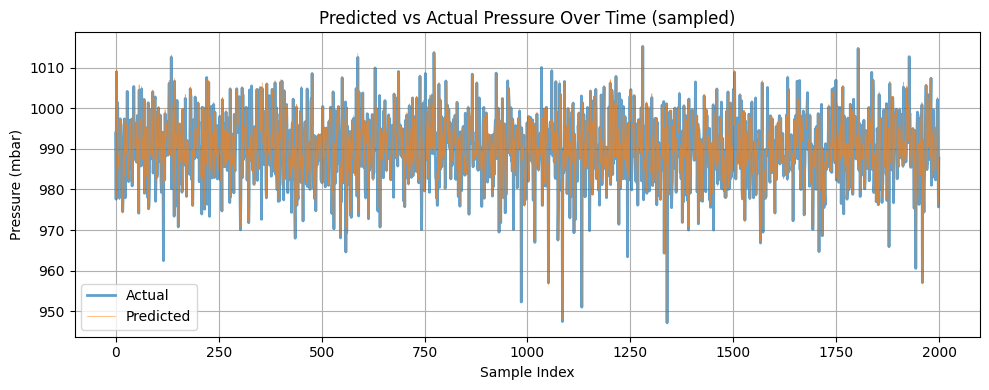

In [ ]:
y_pred_pressure = best_model_pressure.predict(X_test_pressure)
residuals_pressure = y_test_pressure - y_pred_pressure

#1.Actual vs Predicted Scatter
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pressure, y_pred_pressure, alpha=0.3, edgecolor='k')
plt.plot([y_test_pressure.min(), y_test_pressure.max()], [y_test_pressure.min(), y_test_pressure.max()], 'r--')
plt.xlabel("Actual Pressure (mbar)")
plt.ylabel("Predicted Pressure (mbar)")
plt.title("Actual vs Predicted Pressure")
plt.grid(True)
plt.tight_layout()
plt.show()

#2.Residual Histogram
plt.figure(figsize=(8, 4))
plt.hist(residuals_pressure, bins=50, edgecolor='k', alpha=0.7)
plt.title("Pressure Residual Distribution")
plt.xlabel("Residual (mbar)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#3.Time Series Plot
plt.figure(figsize=(10, 4))
sample_idx = np.random.choice(len(y_test_pressure), size=2000, replace=False)
plt.plot(y_test_pressure.iloc[sample_idx].reset_index(drop=True), label="Actual", alpha=0.7, linewidth = 2)
plt.plot(pd.Series(y_pred_pressure).iloc[sample_idx].reset_index(drop=True), label="Predicted", alpha=0.7, linewidth = 0.5)
plt.legend()
plt.title("Predicted vs Actual Pressure Over Time (sampled)")
plt.xlabel("Sample Index")
plt.ylabel("Pressure (mbar)")
plt.grid(True)
plt.tight_layout()
plt.show()


***1. Actual vs Predicted Scatter Plot:***

Data points fall extremely close to the diagonal line, confirming that the model’s predictions align very closely with actual values.

***2. Residual Distribution:***

Residuals (prediction errors) are tightly centered around zero and symmetrically distributed, indicating no systematic bias and confirming strong model calibration.

***3. Time Series Plot:***

The predicted pressure curve almost perfectly overlaps the actual pressure curve, even across a broad sample range. This shows that the model maintains consistent performance across time.

***Conclusion***

Atmospheric pressure tends to be a very stable and smooth variable, especially over short time intervals. Unlike temperature or wind speed, which fluctuate more frequently, pressure changes gradually and predictably. This makes it more amenable to accurate modeling.

# ***Exploring Weather Risk Scenarios Through Prediction Models***

As an important next step, we could explore how combinations of these forecasts might signal hazardous weather conditions.

The following scenarios present hypothetical rules, derived from meteorological knowledge and the behavior observed in the data.

These combinations illustrate how predictions of our target values, if monitored together, could potentially support early warning for weather-related health risks or physical damage.

Even though we did not include such system in this project, these examples show how data mining can lay the foundation for more advanced risk detection in real-world applications.

### ⚠️ Weather Risk Conditions Derived from Model Predictions

| **Condition**          | **Trigger Combination**                                          | **Risk / Interpretation**                                              |
|------------------------|------------------------------------------------------------------|------------------------------------------------------------------------|
| 🌪️ Storm Alert         | `Pressure < 995 mbar` **and** `Wind Speed > 10 m/s`              | Possible cyclone or storm system forming — issue early warnings        |
| 🔥 Heatwave / Wildfire | `Temp > 30°C` **and** `Humidity < 30%` **and** `Wind > 5 m/s`     | Dry, hot, and breezy conditions — high wildfire and heat stress risk   |
| 🌫️ Fog Risk            | `Humidity > 95%` **and** `Wind Speed < 1 m/s`                    | High moisture stagnation — fog or smog buildup likely                   |
| ❄️ Freezing Rain       | `Temp between -2°C and 2°C` **and** `Humidity > 90%`             | Risk of ice formation — hazardous roads and power lines                |
| 🌡️ Climate Shift       | Rising **average annual temperature** over the years             | Long-term trend — possible indicator of local climate change           |
